In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from PIL import Image
import pywt.data

from src.encoding import QuantumImageEncoder
from src.hqwt_1d import qhaar_1d, qhaar_1d_inverse
from src.hqwt_2d import qhaar_2d, qhaar_2d_inverse
from src.d4qwt_1d import Dp_2n, Dp_2n_inverse, F_2n, F_2n_inverse
from src.d4qwt_2d import qd4_2d, qd4_2d_inverse

### Encoding test

In [ ]:
matrix = np.random.rand(512, 512)
encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)
state = encode()
expected = matrix.flatten() / np.linalg.norm(matrix.flatten())
print("Encoding correct:", np.allclose(state, expected))

Encoding correct: True


In [5]:
img = Image.open("../results/IISc.png")
img_gray = img.convert("L")
matrix = np.array(img_gray, dtype=float)

print("Shape:", matrix.shape)

circuit, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

print(qml.draw(circuit)())

Shape: (512, 512)
 0: ─╭|Ψ⟩─┤  State
 1: ─├|Ψ⟩─┤  State
 2: ─├|Ψ⟩─┤  State
 3: ─├|Ψ⟩─┤  State
 4: ─├|Ψ⟩─┤  State
 5: ─├|Ψ⟩─┤  State
 6: ─├|Ψ⟩─┤  State
 7: ─├|Ψ⟩─┤  State
 8: ─├|Ψ⟩─┤  State
 9: ─├|Ψ⟩─┤  State
10: ─├|Ψ⟩─┤  State
11: ─├|Ψ⟩─┤  State
12: ─├|Ψ⟩─┤  State
13: ─├|Ψ⟩─┤  State
14: ─├|Ψ⟩─┤  State
15: ─├|Ψ⟩─┤  State
16: ─├|Ψ⟩─┤  State
17: ─╰|Ψ⟩─┤  State


## Test 1D Quantum Haar Wavelet Transform 

In [6]:
matrix = np.random.rand(8, 8)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten() / np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qhaar_1d(range(n_qubits))
    qhaar_1d_inverse(range(n_qubits))
    return qml.state()

original = encode()
reconstructed = circuit()

print("Haar 1D correct:", np.allclose(original, reconstructed))

Haar 1D correct: True


## Test 2D Quantum Haar Wavelet Transform 

In [ ]:
@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten() / np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qhaar_2d(range(n_qubits), spatial)
    qhaar_2d_inverse(range(n_qubits), spatial)
    return qml.state()
reconstructed = circuit()
print("Haar 2D correct:", np.allclose(original, reconstructed))

Haar 2D correct: True


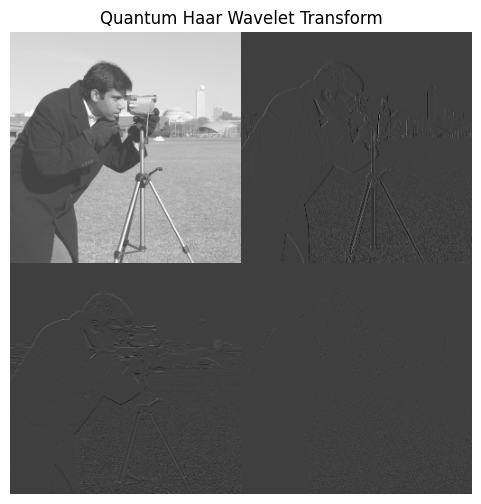

In [8]:
img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten() / np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qhaar_2d(range(n_qubits), spatial)
    return qml.state()

state = circuit()

norm = np.linalg.norm(matrix.flatten())
coeffs = np.real(state) * norm

transformed_image = coeffs.reshape(matrix.shape)

plt.figure(figsize=(6,6))
plt.imshow(transformed_image, cmap='gray')
plt.title("Quantum Haar Wavelet Transform")
plt.axis('off')
plt.show()

## Test 1D Daubechies 4 (D4) Quantum Wavelet Transform 

In [9]:
dev = qml.device("default.qubit", wires=[0,1,2,3])

@qml.qnode(dev)
def test():
    wires = [0,1,2,3]
    Dp_2n(wires)
    Dp_2n_inverse(wires)
    return qml.state()

state = test()
expected = np.array([1] + [0]*15)

print("Dp operator correct:", np.allclose(state, expected))

Dp operator correct: True


## Test F₂ⁿ (D4 QWT 1D test)

In [ ]:
n = 4
dim = 2**n

vector = np.random.rand(dim)
vector = vector / np.linalg.norm(vector)

dev = qml.device("default.qubit", wires=n)

@qml.qnode(dev)
def test():
    qml.AmplitudeEmbedding(vector, wires=range(n), normalize=False)
    F_2n(range(n))
    F_2n_inverse(range(n))
    return qml.state()

reconstructed = test()

print("D4 1D correct:", np.allclose(vector, reconstructed))

## Test 2D Daubechies 4 (D4) Quantum Wavelet Transform 

In [10]:
matrix = np.random.rand(512,512)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def test():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qd4_2d(range(n_qubits), spatial)
    qd4_2d_inverse(range(n_qubits), spatial)
    return qml.state()

original = encode()
reconstructed = test()

print("D4 2D correct:", np.allclose(original, reconstructed))

D4 2D correct: True


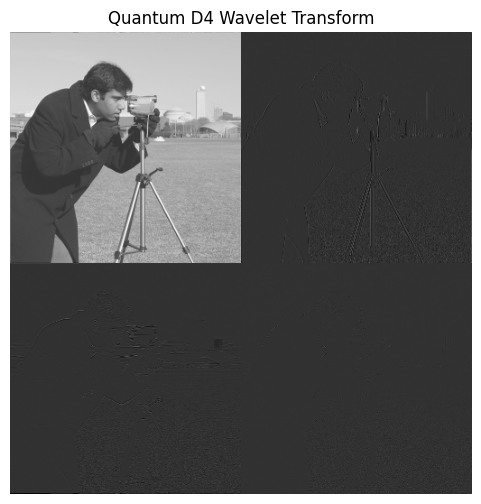

In [11]:
img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qd4_2d(range(n_qubits), spatial)
    return qml.state()

state = circuit()

norm = np.linalg.norm(matrix.flatten())
coeffs = np.real(state) * norm

transformed_image = coeffs.reshape(matrix.shape)

plt.figure(figsize=(6,6))
plt.imshow(transformed_image, cmap='gray')
plt.title("Quantum D4 Wavelet Transform")
plt.axis('off')
plt.show()

### Test multilevel QWT

In [ ]:
import pennylane as qml
import numpy as np

from multilevel_QWT import multilevel_qwt, multilevel_qwt_inverse


matrix = np.random.rand(8,8)
vector = matrix.flatten()
vector = vector/np.linalg.norm(vector)
n = 3
m = 3
n_qubits = n + m
spatial = (n,m)
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def test():
    qml.AmplitudeEmbedding(vector, wires=range(n_qubits), normalize=False)
    multilevel_qwt(range(n_qubits), spatial, levels=2)
    multilevel_qwt_inverse(range(n_qubits), spatial, levels=2)
    return qml.state()
state = test()
print(np.allclose(state, vector))

True


shape: (512, 512)
qubits: 18
spatial: (9, 9)


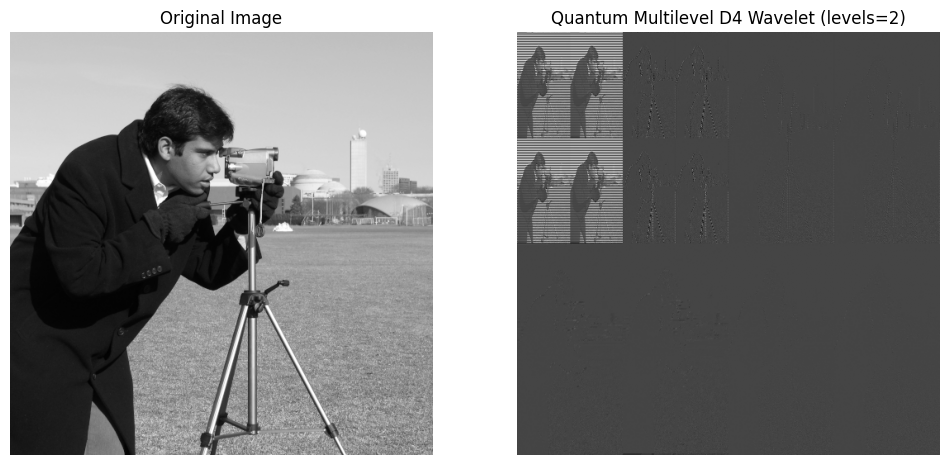

In [ ]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np
import pywt.data

from encoding import QuantumImageEncoder
from multilevel_QWT import multilevel_qwt

img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)
print("shape:", matrix.shape)
print("qubits:", n_qubits)
print("spatial:", spatial)

levels = 2   # choose number of wavelet levels

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_qwt(range(n_qubits), spatial, levels)
    return qml.state()


# ------------------------------------------------
# Run circuit
# ------------------------------------------------

state = circuit()
norm = np.linalg.norm(matrix.flatten())
coeffs = np.real(state) * norm


# reshape coefficients to image grid
transformed_image = coeffs.reshape(matrix.shape)


# ------------------------------------------------
# Visualization
# ------------------------------------------------

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(matrix, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(transformed_image, cmap='gray')
plt.title(f"Quantum Multilevel D4 Wavelet (levels={levels})")
plt.axis('off')

plt.show()

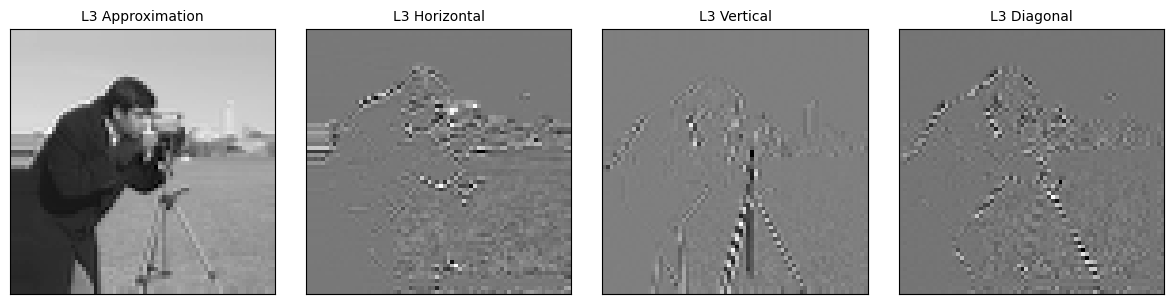

In [ ]:
import matplotlib.pyplot as plt
import pywt
import pywt.data

# 1. Load image
original = pywt.data.camera()

# 2. Set your desired level here
level = 3
wavelet = 'db4'
coeffs = pywt.wavedec2(original, wavelet, level=level)
LL = coeffs[0]
LH, HL, HH = coeffs[1]

# 5. Visualization
titles = [f'L{level} Approximation', f'L{level} Horizontal',
          f'L{level} Vertical', f'L{level} Diagonal']

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, a in enumerate([LL, LH, HL, HH]):
    axes[i].imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    axes[i].set_title(titles[i], fontsize=10)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

fig.tight_layout()
plt.show()

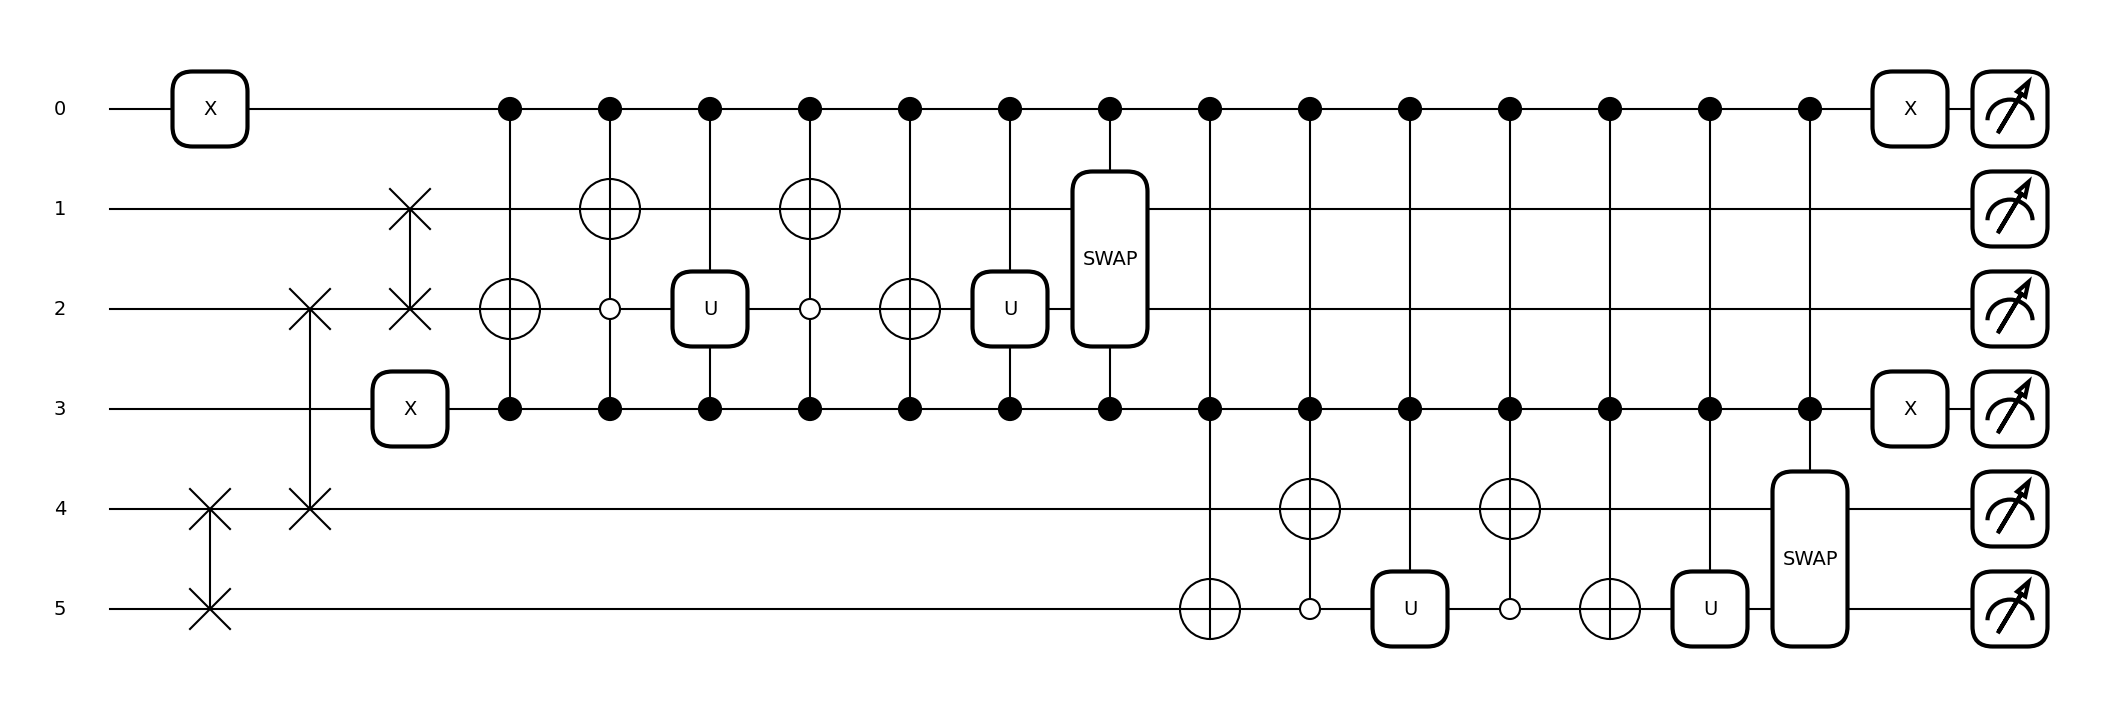

In [ ]:
import pennylane as qml
import matplotlib.pyplot as plt
from permutations import P_2n_2
from multilevel_QWT import T_nm_j, R_nm_j, D_nm_j, L_nm_j


def split_registers(wires, spatial):

    n, m = spatial

    wires = list(wires)

    x_wires = wires[:n]
    y_wires = wires[n:n+m]

    return x_wires, y_wires


# ------------------------------------------------
# T_nm_j  (Fig.8a)
# ------------------------------------------------

def T_nm_j(wires, spatial, j):

    n, m = spatial
    x_wires, y_wires = split_registers(wires, spatial)

    # controls (open circles)
    controls = x_wires[:j-1] + y_wires[:j-1]

    # active qubits
    active_x = x_wires[j-1:]
    active_y = y_wires[j-1:]

    active = active_x + active_y

    # permutation
    P_2n_2(active)

    # apply kernel
    if len(controls) == 0:

        qd4_2d(active, (len(active_x), len(active_y)))

    else:

        qml.ctrl(
            qd4_2d,
            control=controls,
            control_values=[0]*len(controls)
        )(active, (len(active_x), len(active_y)))




n = 3
m = 3
spatial = (n, m)

wires = list(range(n + m))

dev = qml.device("default.qubit", wires=n+m)
@qml.qnode(dev)
def draw_T():

    T_nm_j(wires, spatial, j=2)

    return qml.state()


qml.draw_mpl(draw_T)()
plt.show()

In [ ]:
import pennylane as qml
import matplotlib.pyplot as plt
from permutations import P_2n_2
from multilevel_QWT import T_nm_j, R_nm_j, D_nm_j, L_nm_j


def split_registers(wires, spatial):

    n, m = spatial

    wires = list(wires)

    x_wires = wires[:n]
    y_wires = wires[n:n+m]

    return x_wires, y_wires


# ------------------------------------------------
# T_nm_j  (Fig.8a)
# ------------------------------------------------

def T_nm_j(wires, spatial, j):

    n, m = spatial
    x_wires, y_wires = wires[:n], wires[n:n+m]
    x_wires, y_wires = split_registers(wires, spatial)

    # controls (open circles)
    controls = x_wires[:j-1] + y_wires[:j-1]

    # active qubits
    active_x = x_wires[j-1:]
    active_y = y_wires[j-1:]

    active = active_x + active_y

    # permutation
    P_2n_2(active)

    # apply kernel
    if len(controls) == 0:

        qd4_2d(active, (len(active_x), len(active_y)))

    else:

        qml.ctrl(
            qd4_2d,
            control=controls,
            control_values=[0]*len(controls)
        )(active, (len(active_x), len(active_y)))




n = 3
m = 3
spatial = (n, m)

wires = list(range(n + m))

dev = qml.device("default.qubit", wires=n+m)
@qml.qnode(dev)
def draw_T():

    T_nm_j(wires, spatial, j=2)

    return qml.state()


qml.draw_mpl(draw_T)()
plt.show()

In [ ]:
j = 2
n = 4
m = 3

# Corrected the 2j to 2*j
wires = list(range(n + m - 2*j + 4))

# Corrected the 2j to 2*j
# x_wires uses a slice (which is a list), so [::-1] works.
x_wires = wires[m-j+1 : n+m-2*j+2][::-1]

# y_wires: if you want a list containing that single element reversed:
y_wires = wires[m-j+1 : m-j+2][::-1] 

print("wires:  ", wires)
print("x_wires:", x_wires)
print("y_wires:", y_wires)


wires:   [0, 1, 2, 3, 4, 5, 6]
x_wires: [4, 3, 2]
y_wires: [2]


In [ ]:
def T_nm_j(wires, spatial, j):
        n, m = spatial
        y_wires, x_wires,  = wires[-1:-(m-j+2):-1], wires[-(m-j+2):-(m-j+2+n-j+1):-1]
        active_x = x_wires + wires[1]
        
        P_2n_2(active_x)
        controls = wires[:2]
        qml.ctrl(
            qd4_2d,
            control=x_wires+controls,
            control_values=[0]*len(controls)
        )(x_wires, (len(active_x)))
        
        return x_wires, y_wires
m = 2
n = 3
j = 2
wires = list(range(n + m - 2*j + 4))
print(T_nm_j(wires, (n,m), j))

([3, 2], [4])
